# Camera frame

Open camera → grab frame → compare with the last frame worth sending.

In [2]:
import time

import cv2
import numpy as np
from IPython.display import display
from PIL import Image

In [3]:
if "CAP" in globals():
    CAP.release()  # rerunning this cell: drop the old handle, otherwise the new one inherits its auto-exposure
CAP = cv2.VideoCapture(0)  # 0 = built-in camera. Stays open: every reopen restarts auto-exposure
WARMUP = []  # frame brightness while auto-exposure settles; checked in the next cell
for _ in range(60):
    ok, frame = CAP.read()
    assert ok, "camera returned no frame"
    WARMUP.append(frame.mean())


def grab() -> Image.Image:
    ok, frame = CAP.read()
    assert ok, "camera returned no frame"
    return Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))  # OpenCV stores BGR

In [4]:
# Why the camera stays open: auto-exposure after VideoCapture(0) starts dark, overshoots around
# frame 10-15 and settles by ~frame 40. The old grab() reopened the camera and took frame 10 every time.
# (No ramp at all means another process already had the camera running: the stream is shared.)
print("frame brightness:", "  ".join(f"{i}:{WARMUP[i]:.0f}" for i in (0, 5, 10, 15, 20, 30, 40, 50, 59)))
ramp, settled = np.ptp(WARMUP[:40]), np.ptp(WARMUP[40:])  # a person moving adds a few levels, the ramp adds ~100
assert settled < max(ramp, 5), f"brightness still drifting after warm-up: ramp {ramp:.0f}, after {settled:.0f}"

frame brightness: 0:125  5:124  10:124  15:124  20:124  30:124  40:124  50:124  59:124


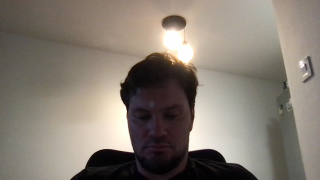

In [5]:
anchor = grab()  # the last frame "sent to the model"
anchor.reduce(4)  # small preview: full frames as outputs bloat the notebook and break the RTC sync

## Did anything change?

The gate from `frame_gate.ipynb`, applied to live frames. Rules:

- compare with the **anchor**, the last frame actually sent, not with the previous frame;
- diff in **Lab**, not grey: brightness (L) is centred so a lamp changes nothing, colour (a, b) still counts;
- score the **loudest tile**, not the frame average: a small change drowns in sensor grain otherwise;
- keep the **camera open**: reopening restarts auto-exposure, and its overshoot around frame 10 lights up every tile;
- loud tiles over **half the board** is light or exposure, not an object: not sent, but once it holds it becomes the new anchor;
- a change must **hold PERSIST frames in the same tiles**: a hand passing left to right is two changes, not one scene.

In [6]:
GATE_SIZE = (128, 72)  # width, height; 16x9 px per tile
GRID = 8               # 8x8 board of tiles
THRESHOLD = 6.6        # Lab levels in the loudest tile; recalibrate on your empty room
GLOBAL = 0.5           # loud tiles over this share of the board: light or exposure changed, not an object
PERSIST = 2            # frames in a row a change must hold before it is worth sending
OVERLAP = 0.5          # share of loud tiles that must repeat from the previous frame: same change, not a passing hand


def prep(x: Image.Image) -> np.ndarray:
    """Small, blurred Lab. L is centred: a lamp moves the mean, not the room."""
    x = cv2.resize(np.asarray(x), GATE_SIZE, interpolation=cv2.INTER_AREA)
    x = cv2.GaussianBlur(cv2.cvtColor(x, cv2.COLOR_RGB2LAB), (0, 0), 2).astype(np.float32)
    x[..., 0] -= x[..., 0].mean()
    return x


def difference(a: Image.Image, b: Image.Image) -> np.ndarray:
    """One map of change: the loudest of |ΔL|, |Δa|, |Δb| per pixel. Max, not mean, keeps THRESHOLD on the grey scale."""
    return np.abs(prep(a) - prep(b)).max(axis=2)


def tiles(diff: np.ndarray) -> np.ndarray:
    """GRID x GRID board: mean change per tile."""
    h, w = diff.shape
    return diff.reshape(GRID, h // GRID, GRID, w // GRID).mean(axis=(1, 3))


def verdict(mask: np.ndarray) -> str:
    """mask = board > THRESHOLD. 'skip' | 'change' | 'light'; only 'change' can lead to an API call."""
    # ponytail: a person filling the frame also reads as 'light'; add a frame-to-frame stability check if that bites
    return "light" if mask.mean() > GLOBAL else "change" if mask.any() else "skip"

In [7]:
# Check on the anchor itself, no second capture needed.
base = Image.eval(anchor, lambda p: 30 + p * 0.7)  # headroom: +20 below must not clip at 255
covered = np.asarray(base).copy()
covered[:90, :160] = 0  # black out one tile (1280x720 / 8)
covered = Image.fromarray(covered)
lamp = Image.eval(base, lambda p: p + 20)           # brighter room: the mean moves, the picture does not
exposure = Image.eval(base, lambda p: p // 2 + 60)  # camera re-exposed: contrast changes in every tile that has any
grey, tinted = np.asarray(base).copy(), np.asarray(base).copy()
grey[:90, :160], tinted[:90, :160] = 128, (200, 96, 128)  # same luma (~130), different colour: a grey diff misses it
grey, tinted = Image.fromarray(grey), Image.fromarray(tinted)

board = lambda a, b: tiles(difference(a, b))
same, shift, object_, colour = (board(base, base).max(), board(base, lamp).max(),
                                board(base, covered).max(), board(grey, tinted).max())
assert same == 0 and shift < THRESHOLD < min(object_, colour), (same, shift, object_, colour)
verdicts = tuple(verdict(board(base, x) > THRESHOLD) for x in (base, lamp, covered))
assert verdicts == ("skip", "skip", "change"), verdicts
share = (board(base, exposure) > THRESHOLD).mean()  # flat tiles (bare wall, ceiling) never get loud: scene-dependent
print(f"same frame {same:.1f} · +20 brightness {shift:.1f} · one tile covered {object_:.1f}"
      f" · one tile recoloured {colour:.1f} · verdicts {verdicts}")
print(f"re-exposed: loud share {share:.2f} -> {verdict(board(base, exposure) > THRESHOLD)}"
      f"  ('light' needs > {GLOBAL}; point the camera at a scene with contrast)")

same frame 0.0 · +20 brightness 3.2 · one tile covered 82.9 · one tile recoloured 39.1 · verdicts ('skip', 'skip', 'change')
re-exposed: loud share 0.80 -> light  ('light' needs > 0.5; point the camera at a scene with contrast)


In [8]:
# Live noise floor: ~5 s of the scene as it is, nothing moving. The loudest tile must stay under THRESHOLD.
first = grab()
noise = 0.0
for _ in range(20):
    time.sleep(0.25)
    noise = max(noise, tiles(difference(first, grab())).max())
print(f"loudest tile over 20 static frames {noise:.1f} vs {THRESHOLD}",
      "-> ok" if noise < THRESHOLD else "-> something moved, or recalibrate THRESHOLD")

loudest tile over 20 static frames 8.4 vs 6.6 -> something moved, or recalibrate THRESHOLD


In [9]:
def heat(board: np.ndarray) -> np.ndarray:
    """Board -> RGB: green 0 -> red 2*THRESHOLD. Same scale everywhere below."""
    red = np.clip(board / (2 * THRESHOLD), 0, 1)
    return np.stack([red * 255, (1 - red) * 200, np.full_like(red, 60)], axis=-1).astype(np.uint8)


def compare(anchor: Image.Image, frame: Image.Image, size=(192, 108)) -> None:
    """Picture of one decision: anchor · frame · difference x8 · tiles."""
    diff = difference(anchor, frame)
    loud = cv2.cvtColor(np.clip(diff * 8, 0, 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)  # changes are a few levels
    panels = [np.asarray(anchor), np.asarray(frame), loud, heat(tiles(diff))]
    display(Image.fromarray(np.hstack([cv2.resize(p, size, interpolation=cv2.INTER_NEAREST) for p in panels])))

 0  change loud 0.17  streak 1 
 1  change loud 0.17  streak 2 -> API CALL


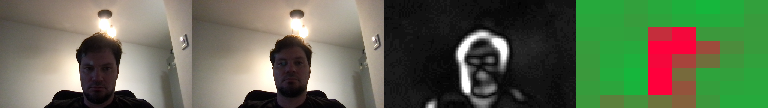

 2  skip   loud 0.00  streak 0 
 3  change loud 0.03  streak 1 
 4  change loud 0.03  streak 2 -> API CALL


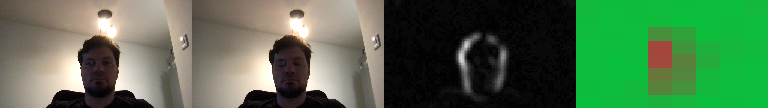

 5  skip   loud 0.00  streak 0 
 6  skip   loud 0.00  streak 0 
 7  skip   loud 0.00  streak 0 
 8  skip   loud 0.00  streak 0 
 9  skip   loud 0.00  streak 0 
10  skip   loud 0.00  streak 0 
11  skip   loud 0.00  streak 0 
12  change loud 0.09  streak 1 
13  change loud 0.09  streak 2 -> API CALL


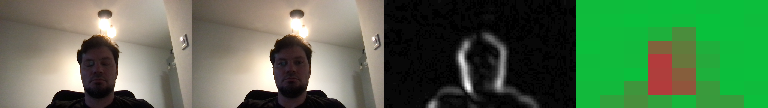

14  change loud 0.08  streak 1 
15  change loud 0.09  streak 2 -> API CALL


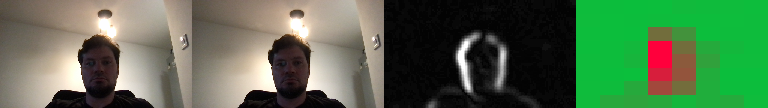

16  skip   loud 0.00  streak 0 
17  skip   loud 0.00  streak 0 
18  skip   loud 0.00  streak 0 
19  skip   loud 0.00  streak 0 


In [12]:
# Watch ~20 s. Put something in view and leave it: a passing hand must not send, a placed object must.
# 'change' held PERSIST frames in the same tiles -> API CALL, anchor moves.
# 'light' held PERSIST frames -> anchor moves too, nothing sent: the room settled into a new baseline.
streak, prev, log = 0, None, []
for i in range(20):
    frame = grab()
    board = tiles(difference(anchor, frame))
    mask = board > THRESHOLD
    v = verdict(mask)
    if v == "skip":
        streak, prev = 0, None
    else:  # same tiles as last frame -> the change holds; new tiles -> a new change, count from 1
        streak = streak + 1 if prev is not None and (mask & prev).sum() / mask.sum() > OVERLAP else 1
        prev = mask
    sent = streak >= PERSIST and v == "change"
    log.append((board, v, sent))
    print(f"{i:2d}  {v:6s} loud {mask.mean():.2f}  streak {streak}",
          "-> API CALL" if sent else "-> new baseline" if streak >= PERSIST else "")
    if sent:
        compare(anchor, frame)  # what goes to the model
    if streak >= PERSIST:
        anchor, streak, prev = frame, 0, None
    time.sleep(1)

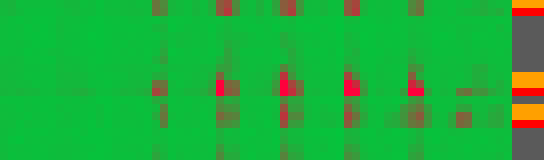

sent: [1, 11, 15]


In [11]:
# Timeline of the run: one row per frame, the 64 tiles left to right (green quiet -> red loud),
# stripe on the right = verdict: grey skip · orange change · blue light · red sent.
COLOUR = {"skip": (90, 90, 90), "change": (255, 160, 0), "light": (70, 130, 255), "sent": (255, 0, 0)}
rows = heat(np.array([b.ravel() for b, _, _ in log]))
stripe = np.array([[COLOUR["sent" if s else v]] * 4 for _, v, s in log], dtype=np.uint8)
display(Image.fromarray(np.hstack([rows, stripe])).resize((68 * 8, len(log) * 8), Image.NEAREST))
print("sent:", [i for i, (_, _, s) in enumerate(log) if s] or "nothing")